<a href="https://colab.research.google.com/github/Tahmidro/phitronNotebooks/blob/main/phitron_machine_learning_linear_regression_implementation_by_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [147]:
df=pd.read_csv("bangladesh_student_performance_updated.csv")

In [148]:
df.shape

(2018, 16)

In [149]:
df.sample(6)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
1137,29/04/2018,M,19.0,Rural,LE3,Together,2,2,Health,Teacher,No,No,54464.0,5,3.68,2.77
1546,29/04/2018,F,18.0,Rural,LE3,Together,0,3,Services,Services,Yes,No,63767.0,3,3.43,2.63
292,29/04/2018,F,18.0,Rural,GT3,Together,2,4,At_home,Farmer,Yes,No,39307.0,4,4.44,3.56
1578,29/04/2018,F,17.0,Urban,GT3,Together,1,3,Services,Services,No,No,108634.0,5,3.58,2.91
614,29/04/2018,F,17.0,Rural,LE3,Together,0,2,Other,Teacher,No,No,54837.0,5,3.79,3.02
1316,29/04/2018,M,17.0,Urban,GT3,Together,3,2,Services,Health,No,No,80424.0,1,3.28,2.75


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


from df info we can get some insight of the columns like we know that date is object type column which can be removed and m edu and f edu is an categorical column although its an int type

In [151]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [152]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [153]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

histplot using pandas

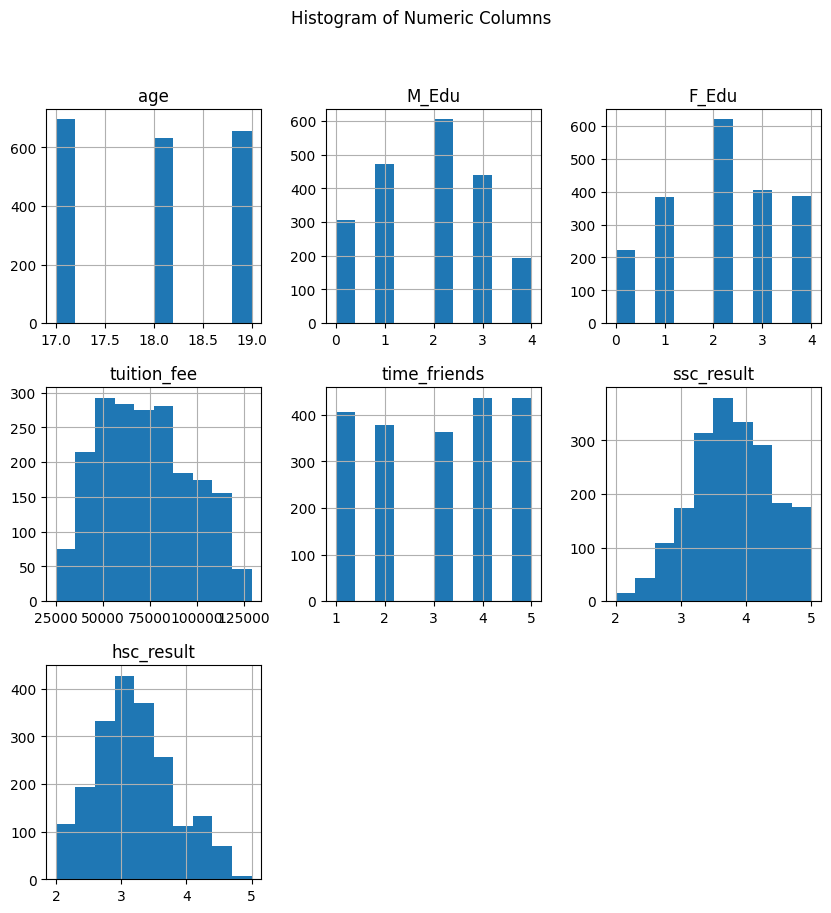

In [154]:
df.hist(bins=10,figsize=(10,10))
plt.suptitle("Histogram of Numeric Columns")
plt.show()

by corealtion heatmap we can figure out the corelation of each features with the features.the corr( ) will only work on numerical columns

corelation heatmap

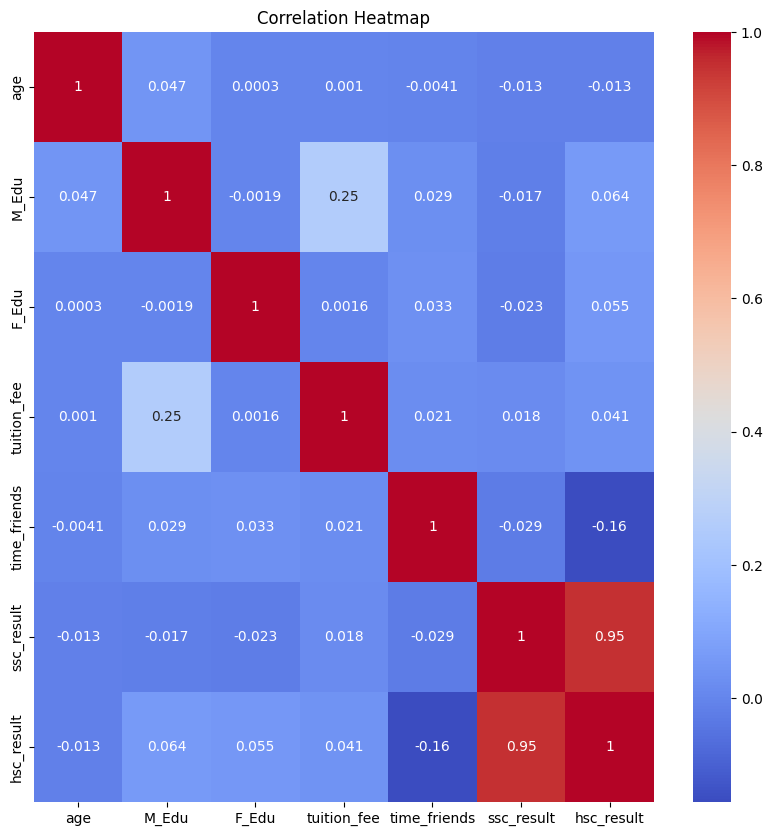

In [155]:
plt.figure(figsize=(10,10))

sns.heatmap(df[["age","M_Edu","F_Edu","tuition_fee","time_friends","ssc_result","hsc_result"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##pipeline

In [156]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

In [157]:
from numpy._core import numeric
nominalCAT=["gender","address","famsize","Pstatus","smoker","M_Job","F_Job","relationship"]
#ordinalCAT=["M_Edu","F_Edu","time_friends"]
numericCAT=["age","tuition_fee","ssc_result"]

##eduOrderM=["0","1","2","3","4"]
##eduOrderF=["0","1","2","3","4"]
##time_friendsOrder=["5","4","3","2","1"]
##jobOrderM=["teacher","health","services","at_home","other"]
##jobOrderF=["teacher","health","services","at_home","other"]

In [158]:
numericalPIPE=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler())
])

In [159]:
nominalPIPE=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

In [160]:
#OrdinalPIPE=Pipeline(steps=[
    #("imputer",SimpleImputer(strategy="most_frequent")),
    #("encoder",OrdinalEncoder(categories=[eduOrderM,eduOrderF,time_friendsOrder,jobOrderM,jobOrderF],handle_unknown='use_encoded_value', unknown_value=-1))
#])

In [161]:
preprocessor=ColumnTransformer(
    transformers=[
    ("nominal",nominalPIPE,nominalCAT),
#("ordinal",OrdinalPIPE,ordinalCAT),
    ("numeric",numericalPIPE,numericCAT)
],remainder="passthrough")

In [162]:
X=df.drop(["date","hsc_result"],axis=1)
y=df["hsc_result"]
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19.0,Rural,LE3,Together,2,2,Other,Services,No,No,49318.0,3,4.95
1381,M,17.0,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032.0,5,2.68
240,F,17.0,Urban,GT3,Together,4,3,Other,Services,No,No,116230.0,4,3.75
1646,M,18.0,Urban,LE3,Apart,2,1,Other,Business,No,No,79334.0,3,3.70
1460,M,18.0,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248.0,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18.0,Rural,GT3,Together,2,2,At_home,Health,No,No,50003.0,1,3.83
1294,F,19.0,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895.0,2,3.30
860,F,19.0,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576.0,1,5.00
1459,F,18.0,Rural,GT3,Together,2,4,Other,Services,No,No,45830.0,1,4.42


In [163]:
from sklearn.linear_model import LinearRegression,SGDRegressor

In [164]:
lrPIPE=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])
lrPIPE.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'smoker', 'M_Job', 'F_Job',
                                                   'relationship']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result'])])),
                ('model', LinearRegression())])

In [165]:
lrPIPE.predict(xtest)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [167]:
SGDPIPE=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",SGDRegressor())
])
SGDPIPE.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'smoker', 'M_Job', 'F_Job',
                                                   'relationship']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result'])])),
                ('model', SGDRegressor())])

In [169]:
from sklearn.metrics  import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

In [171]:
##linear regression

ypred=lrPIPE.predict(xtest)
print(f"mse: {round(mean_squared_error(ytest,ypred),4)}")
print(f"mae: {round(mean_absolute_error(ytest,ypred),4)}")
print(f"r2: {round(r2_score(ytest,ypred),4)}")
print(f"rmse: {round(root_mean_squared_error(ytest,ypred),4)}")

mse: 0.0203
mae: 0.1114
r2: 0.9459
rmse: 0.1425


In [172]:
##SGD regressior

ypred=SGDPIPE.predict(xtest)
print(f"mse: {round(mean_squared_error(ytest,ypred),4)}")
print(f"mae: {round(mean_absolute_error(ytest,ypred),4)}")
print(f"r2: {round(r2_score(ytest,ypred),4)}")
print(f"rmse: {round(root_mean_squared_error(ytest,ypred),4)}")

mse: 0.0201
mae: 0.1112
r2: 0.9463
rmse: 0.1419
